# Codebook-FIGS v2: Joint Gradient Refinement with Elastic-Net Sparsity

This notebook demonstrates **Codebook-FIGS v2**, which extends the Codebook-FIGS framework with three core improvements:

1. **Joint L-BFGS-B optimization** of codebook entries and node thresholds using soft-sigmoid tree predictions
2. **Elastic-net (L1+L2) sparsity penalty** on codebook entries for genuine sparsity
3. **Warm-start tree reassignment** preserving tree structure between alternation rounds

The method benchmarks against FIGS, XGBoost, and LightGBM baselines on tabular classification datasets using stratified cross-validation.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# imodels — NOT on Colab, always install
_pip('imodels==2.0.4')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3',
         'matplotlib==3.10.0', 'xgboost==3.1.3', 'lightgbm==4.6.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.24.0 requires matplotlib>=3.10.8, but you have matplotlib 3.10.0 which is incompatible.
mlxtend 0.24.0 requires numpy>=2.3.5, but you have numpy 2.0.2 which is incompatible.
mlxtend 0.24.0 requires pandas>=2.3.3, but you have pandas 2.2.2 which is incompatible.
mlxtend 0.24.0 requires scikit-learn>=1.8.0, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Optional, Any
from collections import defaultdict

warnings.filterwarnings("ignore")

## Data Loading

Load the demo dataset (breast cancer classification) from GitHub or local fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-5c5e58-codebook-oblique-splits-learning-a-share/main/experiment_iter4_codebook_figs_v/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset(s)")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 1 dataset(s)
  breast_cancer_wdbc: 80 examples


## Configuration

All tunable experiment parameters. Adjust these to control runtime vs. result quality.

In [5]:
# ── Experiment Configuration ──────────────────────────────────────────
# Original values commented; demo uses reduced values for fast execution.

K_VALUES = [3, 5, 8, 12]            # Original: [3, 5, 8, 12] (same)
N_FOLDS = 3                         # Original: 5
MAX_RULES = 12                      # Original: 12 (same)
MAX_DEPTH = 4                       # Original: 4 (same)
N_ALTERNATION_ROUNDS = 10           # Original: 10 (same)
MIN_SAMPLES_LEAF = 5                # Original: 5 (same)
TAU_SOFT = 1.0                      # Original: 1.0 (same)
LAMBDA_L1 = 0.01                    # Original: 0.01 (same)
LAMBDA_L2 = 0.001                   # Original: 0.001 (same)
WEIGHT_THRESHOLD = 0.05             # Original: 0.05 (same)
LBFGS_MAXITER = 30                  # Original: 30 (same)
LBFGS_SUBSAMPLE = 5000              # Original: 5000 (same)

## Section 1: Dataset Parsing

Parse the JSON data into numpy arrays with train/test fold assignments.

In [6]:
def load_datasets(raw: dict) -> Dict[str, Dict[str, Any]]:
    """Load datasets from parsed JSON data."""
    datasets: Dict[str, Dict[str, Any]] = {}

    for group in raw["datasets"]:
        name = group["dataset"]
        examples = group["examples"]
        if len(examples) == 0:
            continue

        meta = examples[0]
        task_type = meta["metadata_task_type"]
        n_classes = meta.get("metadata_n_classes", 0)
        feature_names = meta.get("metadata_feature_names", [])
        domain = meta.get("metadata_domain", "")

        X_list, y_list, fold_list = [], [], []
        for ex in examples:
            X_list.append(json.loads(ex["input"]))
            y_list.append(float(ex["output"]))
            fold_list.append(int(ex["metadata_fold"]))

        X = np.array(X_list, dtype=np.float64)
        y = np.array(y_list, dtype=np.float64)
        folds = np.array(fold_list, dtype=int)

        datasets[name] = {
            "X": X, "y": y, "folds": folds,
            "task_type": task_type, "n_classes": int(n_classes),
            "feature_names": feature_names, "domain": domain,
            "n_features": X.shape[1], "n_samples": X.shape[0],
        }
        print(f"  {name}: n={X.shape[0]}, d={X.shape[1]}, task={task_type}, "
              f"classes={n_classes}, folds={len(np.unique(folds))}")

    print(f"Loaded {len(datasets)} datasets")
    return datasets

datasets = load_datasets(data)

  breast_cancer_wdbc: n=80, d=30, task=classification, classes=2, folds=3
Loaded 1 datasets


## Section 2-3: Node Class & Codebook Initialization

The `Node` class represents oblique tree splits using shared codebook directions. Initialization strategies include PCA-based (adaptive) and random unit vectors.

In [7]:
class Node:
    """Tree node for Codebook-FIGS, supporting oblique splits from a shared codebook."""
    __slots__ = [
        "codebook_idx", "weights", "threshold", "value",
        "idxs", "left", "right", "left_temp", "right_temp",
        "impurity_reduction", "is_root", "tree_num", "depth", "n_samples",
    ]

    def __init__(self) -> None:
        self.codebook_idx: Optional[int] = None
        self.weights: Optional[np.ndarray] = None
        self.threshold: Optional[float] = None
        self.value: float = 0.0
        self.idxs: Optional[np.ndarray] = None
        self.left: Optional["Node"] = None
        self.right: Optional["Node"] = None
        self.left_temp: Optional["Node"] = None
        self.right_temp: Optional["Node"] = None
        self.impurity_reduction: Optional[float] = None
        self.is_root: bool = False
        self.tree_num: int = -1
        self.depth: int = 0
        self.n_samples: int = 0


def init_codebook_pca(X_train: np.ndarray, K: int) -> np.ndarray:
    """Top-K PCA components of centered, scaled X_train."""
    from sklearn.decomposition import PCA

    X_centered = X_train - X_train.mean(axis=0)
    K_actual = min(K, X_train.shape[0], X_train.shape[1])
    pca = PCA(n_components=K_actual)
    pca.fit(X_centered)
    C = pca.components_.copy()

    if K_actual < K:
        rng = np.random.RandomState(42)
        extra = rng.randn(K - K_actual, X_train.shape[1])
        extra = extra / (np.linalg.norm(extra, axis=1, keepdims=True) + 1e-12)
        C = np.vstack([C, extra])

    norms = np.linalg.norm(C, axis=1, keepdims=True)
    C = C / np.maximum(norms, 1e-12)
    return C


def init_codebook_random(X_train: np.ndarray, K: int, seed: int = 42) -> np.ndarray:
    """K random unit vectors."""
    rng = np.random.RandomState(seed)
    C = rng.randn(K, X_train.shape[1])
    C = C / (np.linalg.norm(C, axis=1, keepdims=True) + 1e-12)
    return C


def init_codebook_lda(
    X_train: np.ndarray, y_train: np.ndarray, K: int, task_type: str,
) -> np.ndarray:
    """LDA-inspired init via between-class scatter SVD."""
    try:
        if task_type == "regression":
            n_bins = min(10, max(2, len(np.unique(y_train)) // 2))
            from sklearn.preprocessing import KBinsDiscretizer
            kbd = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="quantile")
            y_binned = kbd.fit_transform(y_train.reshape(-1, 1)).ravel().astype(int)
        else:
            y_binned = y_train.astype(int)

        classes = np.unique(y_binned)
        n_features = X_train.shape[1]
        mu = X_train.mean(axis=0)

        S_B = np.zeros((n_features, n_features))
        for c in classes:
            mask = y_binned == c
            n_c = mask.sum()
            if n_c == 0:
                continue
            mu_c = X_train[mask].mean(axis=0)
            diff = mu_c - mu
            S_B += n_c * np.outer(diff, diff)

        _U, _S_vals, Vt = np.linalg.svd(S_B)
        n_lda = min(len(classes) - 1, n_features, K)
        n_lda = max(n_lda, 1)

        C_lda = Vt[:n_lda].copy()
        norms = np.linalg.norm(C_lda, axis=1, keepdims=True)
        C_lda = C_lda / np.maximum(norms, 1e-12)

        if n_lda < K:
            C_pca = init_codebook_pca(X_train, K)
            C = np.vstack([C_lda, C_pca[n_lda:K]])
        else:
            C = C_lda[:K]

        norms = np.linalg.norm(C, axis=1, keepdims=True)
        C = C / np.maximum(norms, 1e-12)
        return C
    except Exception:
        return init_codebook_pca(X_train, K)


def init_codebook_adaptive(
    X_train: np.ndarray, y_train: np.ndarray, K: int, task_type: str, seed: int = 42,
) -> np.ndarray:
    """Task-adaptive: LDA for classification, PCA for regression."""
    if task_type == "classification":
        return init_codebook_lda(X_train, y_train, K, task_type)
    else:
        return init_codebook_pca(X_train, K)

print("Node class and codebook initialization defined.")

Node class and codebook initialization defined.


## Section 4-5: Split Search & Metrics

`find_best_codebook_split` searches all codebook directions for the best variance-reduction split. Metrics include effective rank (eRank), codebook stability via Hungarian alignment, and sparsity measures.

In [8]:
def find_best_codebook_split(
    X: np.ndarray, y_residuals: np.ndarray, idxs: np.ndarray,
    codebook: np.ndarray, min_samples_leaf: int = 5, quantile_threshold: int = 5000,
) -> Tuple[Optional[int], Optional[float], float, Optional[np.ndarray], Optional[np.ndarray]]:
    """Find best (codebook direction, threshold) split by sorted-scan."""
    node_indices = np.where(idxs)[0]
    n_node = len(node_indices)

    if n_node < 2 * min_samples_leaf:
        return None, None, -np.inf, None, None

    X_node = X[node_indices]
    y_node = y_residuals[node_indices]
    parent_var = np.var(y_node) * n_node

    best_k, best_threshold, best_reduction = None, None, -np.inf
    K = codebook.shape[0]
    use_quantiles = n_node > quantile_threshold
    n_quantiles = 100

    for k in range(K):
        proj = X_node @ codebook[k]
        order = np.argsort(proj)
        sorted_proj = proj[order]
        sorted_y = y_node[order]

        cum_sum = np.cumsum(sorted_y)
        cum_sq_sum = np.cumsum(sorted_y ** 2)
        total_sum = cum_sum[-1]
        total_sq_sum = cum_sq_sum[-1]

        if use_quantiles:
            positions = np.linspace(
                min_samples_leaf - 1, n_node - min_samples_leaf - 1,
                min(n_quantiles, n_node - 2 * min_samples_leaf),
            ).astype(int)
            positions = np.unique(positions)
        else:
            positions = np.arange(min_samples_leaf - 1, n_node - min_samples_leaf)

        for i in positions:
            if i + 1 < n_node and sorted_proj[i] == sorted_proj[i + 1]:
                continue
            n_left = i + 1
            n_right = n_node - n_left
            left_sum = cum_sum[i]
            right_sum = total_sum - left_sum
            left_mse = cum_sq_sum[i] - (left_sum ** 2) / n_left
            right_mse = (total_sq_sum - cum_sq_sum[i]) - (right_sum ** 2) / n_right
            reduction = parent_var - left_mse - right_mse

            if reduction > best_reduction:
                best_reduction = reduction
                best_k = k
                best_threshold = (sorted_proj[i] + sorted_proj[i + 1]) / 2.0 if i + 1 < n_node else sorted_proj[i]

    if best_k is None:
        return None, None, -np.inf, None, None

    full_proj = X @ codebook[best_k]
    idxs_left = idxs & (full_proj <= best_threshold)
    idxs_right = idxs & (full_proj > best_threshold)
    return best_k, best_threshold, best_reduction, idxs_left, idxs_right


def effective_rank(C: np.ndarray, eps: float = 1e-12) -> float:
    """eRank = exp(entropy of normalized singular values)."""
    s = np.linalg.svd(C, compute_uv=False)
    s = s[s > eps]
    if len(s) == 0:
        return 0.0
    p = s / np.sum(s)
    entropy = -np.sum(p * np.log(p + 1e-30))
    return float(np.exp(entropy))


def align_codebooks_hungarian(
    C_ref: np.ndarray, C_target: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Align C_target to C_ref using Hungarian algorithm on |cosine similarity|."""
    from scipy.optimize import linear_sum_assignment
    from sklearn.metrics.pairwise import cosine_similarity

    cos_sim = cosine_similarity(C_ref, C_target)
    abs_cos_sim = np.abs(cos_sim)
    row_ind, col_ind = linear_sum_assignment(abs_cos_sim, maximize=True)

    C_aligned = C_target[col_ind].copy()
    matched_sims = []
    for i in range(len(row_ind)):
        sim = cos_sim[row_ind[i], col_ind[i]]
        matched_sims.append(abs(sim))
        if sim < 0:
            C_aligned[i] *= -1
    return C_aligned, col_ind, np.array(matched_sims)


def compute_codebook_stability(codebooks: List[np.ndarray]) -> Dict[str, Any]:
    """Compute codebook stability across CV folds via Hungarian alignment."""
    if len(codebooks) < 2:
        return {"mean_cosine_sim": 1.0, "min_cosine_sim": 1.0,
                "per_entry_mean_sim": [1.0] * codebooks[0].shape[0],
                "per_entry_std_sim": [0.0] * codebooks[0].shape[0]}

    C_ref = codebooks[0]
    all_sims = []
    for fold_idx in range(1, len(codebooks)):
        _, _, sims = align_codebooks_hungarian(C_ref, codebooks[fold_idx])
        all_sims.append(sims)

    all_sims_arr = np.array(all_sims)
    return {"mean_cosine_sim": float(np.mean(all_sims_arr)),
            "min_cosine_sim": float(np.min(all_sims_arr)),
            "per_entry_mean_sim": all_sims_arr.mean(axis=0).tolist(),
            "per_entry_std_sim": all_sims_arr.std(axis=0).tolist()}


def evaluate_fold(
    y_true: np.ndarray, y_pred: np.ndarray, y_proba: Optional[np.ndarray], task_type: str,
) -> Dict[str, Any]:
    """Compute metrics for one fold."""
    from sklearn.metrics import accuracy_score, roc_auc_score, mean_squared_error, r2_score

    metrics: Dict[str, Any] = {}
    if task_type == "classification":
        metrics["accuracy"] = float(accuracy_score(y_true, y_pred))
        if y_proba is not None:
            try:
                proba_1 = np.clip(y_proba[:, 1], 1e-7, 1 - 1e-7)
                metrics["auroc"] = float(roc_auc_score(y_true, proba_1))
            except ValueError:
                metrics["auroc"] = None
        else:
            metrics["auroc"] = None
        metrics["rmse"] = None
        metrics["r2"] = None
    else:
        metrics["rmse"] = float(np.sqrt(mean_squared_error(y_true, y_pred)))
        metrics["r2"] = float(r2_score(y_true, y_pred))
        metrics["accuracy"] = None
        metrics["auroc"] = None
    return metrics


def compute_codebook_sparsity(codebook: np.ndarray, weight_threshold: float = 0.05) -> Dict[str, Any]:
    """Compute sparsity metrics for each codebook entry."""
    K, d = codebook.shape
    l0_norms, top3_concs = [], []
    for k in range(K):
        abs_w = np.abs(codebook[k])
        l0_norms.append(int(np.sum(abs_w > weight_threshold)))
        total = np.sum(abs_w)
        if total > 1e-12:
            sorted_abs = np.sort(abs_w)[::-1]
            top3_concs.append(float(np.sum(sorted_abs[:min(3, len(sorted_abs))]) / total))
        else:
            top3_concs.append(0.0)
    return {"top3_concentration": float(np.mean(top3_concs)),
            "mean_l0_norm": float(np.mean(l0_norms)),
            "per_entry_l0": l0_norms, "per_entry_top3_conc": top3_concs}

print("Split search, metrics, and sparsity functions defined.")

Split search, metrics, and sparsity functions defined.


## Section 6-9: Core Innovations — Soft Predictions, Joint L-BFGS-B Refinement, Warm-Start & Sparsification

The key v2 contributions:
- **Soft sigmoid routing** makes tree predictions differentiable for gradient optimization
- **Joint L-BFGS-B** optimizes codebook entries AND node thresholds simultaneously  
- **Warm-start reassignment** preserves tree structure while updating splits
- **Elastic-net sparsification** thresholds small weights to zero for genuine sparsity

In [9]:
# ── Section 6: Soft Tree Prediction ──────────────────────────────────

def _collect_internal_nodes_tree(tree_root: Node) -> List[Node]:
    """Collect all internal nodes from a single tree in DFS order."""
    nodes: List[Node] = []
    def _dfs(node: Optional[Node]) -> None:
        if node is None:
            return
        if node.left is not None and node.right is not None:
            nodes.append(node)
            _dfs(node.left)
            _dfs(node.right)
    _dfs(tree_root)
    return nodes


def _collect_all_internal_nodes(trees: List[Node]) -> List[Node]:
    all_nodes: List[Node] = []
    for tree_root in trees:
        all_nodes.extend(_collect_internal_nodes_tree(tree_root))
    return all_nodes


def soft_predict_tree(
    root: Node, X: np.ndarray, codebook: np.ndarray,
    threshold_overrides: Dict[int, float], tau: float, global_id_offset: int = 0,
) -> Tuple[np.ndarray, int]:
    """Compute soft tree predictions using sigmoid routing."""
    n = X.shape[0]

    def _recurse(node: Optional[Node], counter: List[int]) -> np.ndarray:
        if node is None:
            return np.zeros(n)
        if node.left is None or node.right is None:
            return np.full(n, node.value)

        nid = counter[0]
        counter[0] += 1
        k = node.codebook_idx
        t = threshold_overrides.get(nid, node.threshold)
        proj = X @ codebook[k]

        z = (proj - t) / max(tau, 1e-8)
        z = np.clip(z, -500, 500)
        p_right = 1.0 / (1.0 + np.exp(-z))
        p_left = 1.0 - p_right

        left_pred = _recurse(node.left, counter)
        right_pred = _recurse(node.right, counter)
        return p_left * left_pred + p_right * right_pred

    counter = [global_id_offset]
    pred = _recurse(root, counter)
    return pred, counter[0]


def soft_predict_ensemble(
    trees: List[Node], X: np.ndarray, codebook: np.ndarray,
    threshold_overrides: Dict[int, float], tau: float,
) -> np.ndarray:
    """Sum soft predictions across all trees."""
    total = np.zeros(X.shape[0])
    offset = 0
    for tree_root in trees:
        pred, offset = soft_predict_tree(tree_root, X, codebook, threshold_overrides, tau, offset)
        total += pred
    return total


# ── Section 7: Joint L-BFGS-B Refinement ────────────────────────────

def joint_refine_codebook_thresholds(
    trees: List[Node], codebook: np.ndarray, X: np.ndarray, y: np.ndarray,
    lambda_l1: float = 0.01, lambda_l2: float = 0.001, tau: float = 1.0,
    maxiter: int = 30, subsample: int = 5000, random_state: int = 42,
) -> Tuple[np.ndarray, Dict[int, float], Any]:
    """Jointly optimize codebook entries and node thresholds using L-BFGS-B."""
    from scipy.optimize import minimize

    K, d = codebook.shape
    all_nodes = _collect_all_internal_nodes(trees)
    N_nodes = len(all_nodes)

    if N_nodes == 0:
        return codebook.copy(), {}, None

    n_samples = X.shape[0]
    if n_samples > subsample:
        rng = np.random.RandomState(random_state)
        sub_idx = rng.choice(n_samples, subsample, replace=False)
        X_sub, y_sub = X[sub_idx], y[sub_idx]
    else:
        X_sub, y_sub = X, y

    theta0 = np.concatenate([
        codebook.flatten(),
        np.array([node.threshold for node in all_nodes], dtype=np.float64),
    ])
    n_codebook_params = K * d

    def objective(theta: np.ndarray) -> float:
        C = theta[:n_codebook_params].reshape(K, d)
        thresholds = theta[n_codebook_params:]

        threshold_dict: Dict[int, float] = {}
        offset = 0
        for tree_root in trees:
            tree_nodes = _collect_internal_nodes_tree(tree_root)
            for node in tree_nodes:
                threshold_dict[offset] = thresholds[offset] if offset < len(thresholds) else node.threshold
                offset += 1

        y_pred = soft_predict_ensemble(trees, X_sub, C, threshold_dict, tau)
        residuals = y_sub - y_pred
        mse = float(np.mean(residuals ** 2))
        l1_smooth = lambda_l1 * float(np.sum(np.sqrt(C ** 2 + 1e-6)))
        l2_penalty = lambda_l2 * float(np.sum(C ** 2))
        return mse + l1_smooth + l2_penalty

    try:
        result = minimize(
            fun=objective, x0=theta0, method='L-BFGS-B', jac='2-point',
            options={'maxiter': maxiter, 'ftol': 1e-6, 'gtol': 1e-5,
                     'maxfun': maxiter * 5, 'disp': False},
        )
    except Exception:
        return codebook.copy(), {}, None

    theta_opt = result.x
    C_opt = theta_opt[:n_codebook_params].reshape(K, d)
    thresholds_opt = theta_opt[n_codebook_params:]

    if np.any(np.isnan(C_opt)) or np.any(np.isnan(thresholds_opt)):
        return codebook.copy(), {}, result

    threshold_dict_opt: Dict[int, float] = {}
    for i in range(N_nodes):
        threshold_dict_opt[i] = float(thresholds_opt[i])
    return C_opt, threshold_dict_opt, result


# ── Section 8: Warm-Start Tree Reassignment ─────────────────────────

def _hard_predict_tree(root: Node, X: np.ndarray) -> np.ndarray:
    """Hard tree prediction."""
    preds = np.full(X.shape[0], root.value)
    if root.left is not None and root.right is not None:
        proj = X @ root.weights
        left_mask = proj <= root.threshold
        left_preds = _hard_predict_tree(root.left, X)
        right_preds = _hard_predict_tree(root.right, X)
        preds[left_mask] = left_preds[left_mask]
        preds[~left_mask] = right_preds[~left_mask]
    return preds


def _recompute_leaf_values_and_idxs(
    node: Node, X: np.ndarray, y_residuals: np.ndarray,
    parent_idxs: np.ndarray, codebook: np.ndarray,
) -> None:
    """Recursively recompute leaf values and sample indices after changes."""
    node.idxs = parent_idxs
    node.n_samples = int(parent_idxs.sum())

    if node.left is None or node.right is None:
        node.value = float(np.mean(y_residuals[parent_idxs])) if node.n_samples > 0 else 0.0
        return

    proj = X @ codebook[node.codebook_idx]
    left_mask = parent_idxs & (proj <= node.threshold)
    right_mask = parent_idxs & (proj > node.threshold)
    node.weights = codebook[node.codebook_idx].copy()

    _recompute_leaf_values_and_idxs(node.left, X, y_residuals, left_mask, codebook)
    _recompute_leaf_values_and_idxs(node.right, X, y_residuals, right_mask, codebook)

    node.value = float(np.mean(y_residuals[parent_idxs])) if node.n_samples > 0 else 0.0


def warm_start_reassign(
    trees: List[Node], codebook: np.ndarray, X: np.ndarray, y: np.ndarray,
    min_samples_leaf: int = 5,
) -> int:
    """After codebook refinement, reassign codebook entries at existing nodes."""
    n_reassigned = 0
    n_samples = X.shape[0]
    K = codebook.shape[0]

    for tree_idx, tree_root in enumerate(trees):
        y_res = y.copy()
        for other_idx, other_tree in enumerate(trees):
            if other_idx != tree_idx:
                y_res -= _hard_predict_tree(other_tree, X)

        internal_nodes = _collect_internal_nodes_tree(tree_root)
        for node in internal_nodes:
            if node.idxs is None or node.n_samples < 2 * min_samples_leaf:
                continue
            node_indices = np.where(node.idxs)[0]
            if len(node_indices) < 2 * min_samples_leaf:
                continue

            X_node = X[node_indices]
            y_node = y_res[node_indices]
            n_node = len(node_indices)
            parent_var = np.var(y_node) * n_node

            best_k = node.codebook_idx
            best_threshold = node.threshold
            best_reduction = -np.inf

            if best_k is not None:
                proj_curr = X_node @ codebook[best_k]
                mask_left = proj_curr <= node.threshold
                n_left, n_right = mask_left.sum(), n_node - mask_left.sum()
                if n_left >= min_samples_leaf and n_right >= min_samples_leaf:
                    left_var = np.sum((y_node[mask_left] - y_node[mask_left].mean()) ** 2)
                    right_var = np.sum((y_node[~mask_left] - y_node[~mask_left].mean()) ** 2)
                    best_reduction = parent_var - left_var - right_var

            for k in range(K):
                proj = X_node @ codebook[k]
                order = np.argsort(proj)
                sorted_proj = proj[order]
                sorted_y = y_node[order]
                cum_sum = np.cumsum(sorted_y)
                cum_sq_sum = np.cumsum(sorted_y ** 2)
                total_sum, total_sq_sum = cum_sum[-1], cum_sq_sum[-1]

                n_check = min(50, n_node - 2 * min_samples_leaf)
                if n_check <= 0:
                    continue
                positions = np.linspace(
                    min_samples_leaf - 1, n_node - min_samples_leaf - 1, n_check,
                ).astype(int)
                positions = np.unique(positions)

                for i in positions:
                    if i + 1 < n_node and sorted_proj[i] == sorted_proj[i + 1]:
                        continue
                    n_l, n_r = i + 1, n_node - (i + 1)
                    left_sum = cum_sum[i]
                    right_sum = total_sum - left_sum
                    left_mse = cum_sq_sum[i] - (left_sum ** 2) / n_l
                    right_mse = (total_sq_sum - cum_sq_sum[i]) - (right_sum ** 2) / n_r
                    reduction = parent_var - left_mse - right_mse

                    if reduction > best_reduction * 1.01:
                        best_reduction = reduction
                        best_k = k
                        best_threshold = (sorted_proj[i] + sorted_proj[i + 1]) / 2.0 if i + 1 < n_node else sorted_proj[i]

            if best_k != node.codebook_idx or best_threshold != node.threshold:
                node.codebook_idx = best_k
                node.weights = codebook[best_k].copy()
                node.threshold = best_threshold
                n_reassigned += 1

        y_res_tree = y.copy()
        for other_idx, other_tree in enumerate(trees):
            if other_idx != tree_idx:
                y_res_tree -= _hard_predict_tree(other_tree, X)
        root_idxs = np.ones(n_samples, dtype=bool)
        _recompute_leaf_values_and_idxs(tree_root, X, y_res_tree, root_idxs, codebook)

    return n_reassigned


# ── Section 9: Elastic-Net Sparsification ────────────────────────────

def apply_elastic_net_sparsification(codebook: np.ndarray, threshold: float = 0.05) -> np.ndarray:
    """Apply post-optimization sparsification to codebook."""
    K, d = codebook.shape
    C = codebook.copy()
    for k in range(K):
        mask = np.abs(C[k]) < threshold
        C[k, mask] = 0.0
        norm = np.linalg.norm(C[k])
        if norm < 1e-12:
            rng = np.random.RandomState(42 + k)
            C[k] = rng.randn(d)
        C[k] /= np.linalg.norm(C[k]) + 1e-12
    return C

print("Core innovations (soft prediction, L-BFGS-B, warm-start, sparsification) defined.")

Core innovations (soft prediction, L-BFGS-B, warm-start, sparsification) defined.


## Section 10: CodebookFIGS_v2 Class

The main model class combining all components: FIGS-style tree growth, joint L-BFGS-B refinement, elastic-net sparsification, and warm-start reassignment in an alternation loop.

In [10]:
class CodebookFIGS_v2:
    """Codebook-FIGS v2 with joint gradient refinement & elastic-net sparsity."""

    def __init__(
        self, K: int = 8, max_rules: int = 12, max_trees: Optional[int] = None,
        max_depth: int = 4, min_impurity_decrease: float = 0.0,
        n_alternation_rounds: int = 10, init_strategy: str = "adaptive",
        tau: float = 1.0, lambda_l1: float = 0.01, lambda_l2: float = 0.001,
        weight_threshold: float = 0.05, lbfgs_maxiter: int = 30,
        random_state: int = 42, min_samples_leaf: int = 5,
    ) -> None:
        self.K = K
        self.max_rules = max_rules
        self.max_trees = max_trees if max_trees else 10
        self.max_depth = max_depth
        self.min_impurity_decrease = min_impurity_decrease
        self.n_alternation_rounds = n_alternation_rounds
        self.init_strategy = init_strategy
        self.tau = tau
        self.lambda_l1 = lambda_l1
        self.lambda_l2 = lambda_l2
        self.weight_threshold = weight_threshold
        self.lbfgs_maxiter = lbfgs_maxiter
        self.random_state = random_state
        self.min_samples_leaf = min_samples_leaf

        self.trees_: List[Node] = []
        self.codebook_: Optional[np.ndarray] = None
        self.scaler_: Any = None
        self.task_type_: str = "classification"
        self.complexity_: int = 0
        self.history_: Dict[str, list] = {}
        self.converged_at_round_: int = 0
        self.lbfgs_total_iters_: int = 0
        self.lbfgs_total_converged_: int = 0
        self._use_fallback_wls: bool = False

    def fit(self, X: np.ndarray, y: np.ndarray, task_type: str = "classification") -> "CodebookFIGS_v2":
        from sklearn.preprocessing import StandardScaler

        self.task_type_ = task_type
        self.scaler_ = StandardScaler()
        X_s = self.scaler_.fit_transform(X)

        if self.init_strategy == "adaptive":
            self.codebook_ = init_codebook_adaptive(X_s, y, self.K, task_type, self.random_state)
        elif self.init_strategy == "random":
            self.codebook_ = init_codebook_random(X_s, self.K, self.random_state)
        elif self.init_strategy == "pca":
            self.codebook_ = init_codebook_pca(X_s, self.K)
        else:
            raise ValueError(f"Unknown init_strategy: {self.init_strategy}")

        self.history_ = {
            "train_losses": [], "eranks": [], "n_splits": [], "primary_metric": [],
            "codebooks": [], "sparsity_top3": [], "sparsity_l0": [],
            "lbfgs_n_iterations": [], "lbfgs_converged": [],
        }

        initial_loss, prev_loss = None, None
        lbfgs_fail_count = 0

        for round_idx in range(self.n_alternation_rounds):
            if round_idx == 0:
                self._grow_trees_figs_style(X_s, y)
            else:
                all_internal = _collect_all_internal_nodes(self.trees_)
                n_internal = len(all_internal)

                if n_internal >= 2 and not self._use_fallback_wls:
                    try:
                        new_codebook, new_thresholds, opt_result = \
                            joint_refine_codebook_thresholds(
                                self.trees_, self.codebook_, X_s, y,
                                lambda_l1=self.lambda_l1, lambda_l2=self.lambda_l2,
                                tau=self.tau, maxiter=self.lbfgs_maxiter,
                                random_state=self.random_state,
                            )
                        if opt_result is not None:
                            self.lbfgs_total_iters_ += getattr(opt_result, 'nit', 0)
                            if getattr(opt_result, 'success', False):
                                self.lbfgs_total_converged_ += 1
                            self.history_["lbfgs_n_iterations"].append(getattr(opt_result, 'nit', 0))
                            self.history_["lbfgs_converged"].append(getattr(opt_result, 'success', False))
                        else:
                            self.history_["lbfgs_n_iterations"].append(0)
                            self.history_["lbfgs_converged"].append(False)

                        if np.all(np.isfinite(new_codebook)):
                            self.codebook_ = new_codebook
                            offset = 0
                            for tree_root in self.trees_:
                                tree_nodes = _collect_internal_nodes_tree(tree_root)
                                for node in tree_nodes:
                                    if offset in new_thresholds:
                                        node.threshold = new_thresholds[offset]
                                    node.weights = self.codebook_[node.codebook_idx].copy()
                                    offset += 1
                        else:
                            lbfgs_fail_count += 1

                    except Exception:
                        lbfgs_fail_count += 1
                        self.history_["lbfgs_n_iterations"].append(0)
                        self.history_["lbfgs_converged"].append(False)
                        if lbfgs_fail_count >= 3:
                            self._use_fallback_wls = True
                elif self._use_fallback_wls or n_internal < 2:
                    self._refine_codebook_wls(X_s, y)
                    self.history_["lbfgs_n_iterations"].append(0)
                    self.history_["lbfgs_converged"].append(False)

                self.codebook_ = apply_elastic_net_sparsification(self.codebook_, threshold=self.weight_threshold)
                for tree_root in self.trees_:
                    self._update_node_weights(tree_root)

                n_reassigned = warm_start_reassign(self.trees_, self.codebook_, X_s, y,
                                                    min_samples_leaf=self.min_samples_leaf)
                self._check_codebook_collapse()

            preds = self._predict_raw(X_s)
            loss = float(np.mean((y - preds) ** 2))

            if task_type == "classification":
                metric = float(np.mean((preds >= 0.5).astype(int) == y.astype(int)))
            else:
                ss_res = np.sum((y - preds) ** 2)
                ss_tot = np.sum((y - y.mean()) ** 2)
                metric = 1.0 - ss_res / max(ss_tot, 1e-12)

            sparsity = compute_codebook_sparsity(self.codebook_, self.weight_threshold)
            self.history_["train_losses"].append(loss)
            self.history_["primary_metric"].append(float(metric))
            self.history_["eranks"].append(effective_rank(self.codebook_))
            self.history_["n_splits"].append(self.complexity_)
            self.history_["codebooks"].append(self.codebook_.copy())
            self.history_["sparsity_top3"].append(sparsity["top3_concentration"])
            self.history_["sparsity_l0"].append(sparsity["mean_l0_norm"])

            if round_idx == 0 and len(self.history_["lbfgs_n_iterations"]) == 0:
                self.history_["lbfgs_n_iterations"].append(0)
                self.history_["lbfgs_converged"].append(False)

            if initial_loss is None:
                initial_loss = loss
            if round_idx > 0 and prev_loss is not None and initial_loss and initial_loss > 0:
                if abs(loss - prev_loss) < 0.003 * initial_loss:
                    self.converged_at_round_ = round_idx + 1
                    self._grow_trees_figs_style(X_s, y)
                    break
            prev_loss = loss

        if self.converged_at_round_ == 0:
            self.converged_at_round_ = len(self.history_["train_losses"])
            self._grow_trees_figs_style(X_s, y)

        return self

    def _grow_trees_figs_style(self, X: np.ndarray, y: np.ndarray) -> None:
        n_samples = X.shape[0]
        self.trees_ = []
        self.complexity_ = 0
        y_pred_per_tree: Dict[int, np.ndarray] = {}
        all_idxs = np.ones(n_samples, dtype=bool)

        bk, bt, br, il, ir = find_best_codebook_split(X, y, all_idxs, self.codebook_, self.min_samples_leaf)
        if bk is None:
            root = Node()
            root.is_root = True
            root.tree_num = 0
            root.idxs = all_idxs
            root.value = float(np.mean(y))
            root.n_samples = n_samples
            self.trees_.append(root)
            return

        root = Node()
        root.is_root = True
        root.tree_num = -1
        root.idxs = all_idxs
        root.value = float(np.mean(y))
        root.impurity_reduction = br
        root.codebook_idx = bk
        root.weights = self.codebook_[bk].copy()
        root.threshold = bt
        root.depth = 0
        root.n_samples = n_samples

        root.left_temp = Node()
        root.left_temp.idxs = il
        root.left_temp.value = float(np.mean(y[il])) if il.sum() > 0 else 0.0
        root.left_temp.n_samples = int(il.sum())
        root.left_temp.depth = 1

        root.right_temp = Node()
        root.right_temp.idxs = ir
        root.right_temp.value = float(np.mean(y[ir])) if ir.sum() > 0 else 0.0
        root.right_temp.n_samples = int(ir.sum())
        root.right_temp.depth = 1

        potential_splits: List[Node] = [root]
        max_new_trees = self.max_trees

        while potential_splits and self.complexity_ < self.max_rules:
            potential_splits.sort(
                key=lambda n: n.impurity_reduction if n.impurity_reduction is not None else -np.inf,
                reverse=True,
            )
            best_node = potential_splits.pop(0)

            if best_node.impurity_reduction is None or best_node.impurity_reduction < self.min_impurity_decrease:
                break
            if self.max_depth is not None and best_node.depth >= self.max_depth:
                continue

            if best_node.is_root:
                if len(self.trees_) >= max_new_trees:
                    continue
                best_node.tree_num = len(self.trees_)
                self.trees_.append(best_node)
                y_pred_per_tree[best_node.tree_num] = np.full(n_samples, best_node.value)

            self.complexity_ += 1
            best_node.left = best_node.left_temp
            best_node.right = best_node.right_temp
            best_node.left.tree_num = best_node.tree_num
            best_node.right.tree_num = best_node.tree_num
            best_node.left_temp = None
            best_node.right_temp = None

            tree_root = self.trees_[best_node.tree_num]
            y_pred_per_tree[best_node.tree_num] = self._predict_tree(tree_root, X)

            for child in [best_node.left, best_node.right]:
                if child.n_samples < 2 * self.min_samples_leaf:
                    continue
                y_res = y.copy()
                for other_t, pred in y_pred_per_tree.items():
                    if other_t != child.tree_num:
                        y_res -= pred

                bk2, bt2, br2, il2, ir2 = find_best_codebook_split(
                    X, y_res, child.idxs, self.codebook_, self.min_samples_leaf,
                )
                if bk2 is not None and br2 > self.min_impurity_decrease:
                    child.codebook_idx = bk2
                    child.weights = self.codebook_[bk2].copy()
                    child.threshold = bt2
                    child.impurity_reduction = br2

                    child.left_temp = Node()
                    child.left_temp.idxs = il2
                    child.left_temp.value = float(np.mean(y_res[il2])) if il2.sum() > 0 else 0.0
                    child.left_temp.n_samples = int(il2.sum())
                    child.left_temp.depth = child.depth + 1

                    child.right_temp = Node()
                    child.right_temp.idxs = ir2
                    child.right_temp.value = float(np.mean(y_res[ir2])) if ir2.sum() > 0 else 0.0
                    child.right_temp.n_samples = int(ir2.sum())
                    child.right_temp.depth = child.depth + 1

                    potential_splits.append(child)

            if len(self.trees_) < max_new_trees:
                y_total = sum(y_pred_per_tree.values())
                y_res_new = y - y_total

                bk3, bt3, br3, il3, ir3 = find_best_codebook_split(
                    X, y_res_new, np.ones(n_samples, dtype=bool),
                    self.codebook_, self.min_samples_leaf,
                )
                if bk3 is not None and br3 > self.min_impurity_decrease:
                    new_root = Node()
                    new_root.is_root = True
                    new_root.tree_num = -1
                    new_root.idxs = np.ones(n_samples, dtype=bool)
                    new_root.value = float(np.mean(y_res_new))
                    new_root.impurity_reduction = br3
                    new_root.codebook_idx = bk3
                    new_root.weights = self.codebook_[bk3].copy()
                    new_root.threshold = bt3
                    new_root.depth = 0
                    new_root.n_samples = n_samples

                    new_root.left_temp = Node()
                    new_root.left_temp.idxs = il3
                    new_root.left_temp.value = float(np.mean(y_res_new[il3])) if il3.sum() > 0 else 0.0
                    new_root.left_temp.n_samples = int(il3.sum())
                    new_root.left_temp.depth = 1

                    new_root.right_temp = Node()
                    new_root.right_temp.idxs = ir3
                    new_root.right_temp.value = float(np.mean(y_res_new[ir3])) if ir3.sum() > 0 else 0.0
                    new_root.right_temp.n_samples = int(ir3.sum())
                    new_root.right_temp.depth = 1

                    potential_splits.append(new_root)

    def _refine_codebook_wls(self, X: np.ndarray, y: np.ndarray) -> None:
        K, n_features = self.codebook_.shape
        for k in range(K):
            nodes_k: List[Node] = []
            for tree in self.trees_:
                self._collect_nodes_with_idx(tree, k, nodes_k)
            if not nodes_k:
                rng = np.random.RandomState(self.random_state + k + 200)
                self.codebook_[k] = rng.randn(n_features)
                self.codebook_[k] /= np.linalg.norm(self.codebook_[k]) + 1e-12
                continue
            X_pool_list, y_res_list = [], []
            for node in nodes_k:
                y_res = y.copy()
                for t_idx, tree in enumerate(self.trees_):
                    if t_idx != node.tree_num:
                        y_res -= self._predict_tree(tree, X)
                if node.idxs is not None:
                    X_pool_list.append(X[node.idxs])
                    y_res_list.append(y_res[node.idxs])
            if not X_pool_list:
                continue
            X_pool = np.vstack(X_pool_list)
            y_pool = np.concatenate(y_res_list)
            direction = X_pool.T @ y_pool
            norm = np.linalg.norm(direction)
            if norm > 1e-12:
                self.codebook_[k] = direction / norm

    def _collect_nodes_with_idx(self, node: Optional[Node], k: int, result: List[Node]) -> None:
        if node is None:
            return
        if node.left is not None and node.right is not None:
            if node.codebook_idx == k:
                result.append(node)
            self._collect_nodes_with_idx(node.left, k, result)
            self._collect_nodes_with_idx(node.right, k, result)

    def _update_node_weights(self, node: Optional[Node]) -> None:
        if node is None:
            return
        if node.left is not None and node.right is not None:
            if node.codebook_idx is not None:
                node.weights = self.codebook_[node.codebook_idx].copy()
            self._update_node_weights(node.left)
            self._update_node_weights(node.right)

    def _check_codebook_collapse(self) -> int:
        from sklearn.metrics.pairwise import cosine_similarity
        K, n_feat = self.codebook_.shape[0], self.codebook_.shape[1]
        cos_sim = np.abs(cosine_similarity(self.codebook_))
        np.fill_diagonal(cos_sim, 0.0)
        n_collapses = 0
        for i in range(K):
            for j in range(i + 1, K):
                if cos_sim[i, j] > 0.99:
                    rng = np.random.RandomState(self.random_state + 100 + j)
                    self.codebook_[j] = rng.randn(n_feat)
                    self.codebook_[j] /= np.linalg.norm(self.codebook_[j]) + 1e-12
                    n_collapses += 1
        return n_collapses

    def _predict_tree(self, root: Node, X: np.ndarray) -> np.ndarray:
        preds = np.full(X.shape[0], root.value)
        if root.left is not None and root.right is not None:
            proj = X @ root.weights
            left_mask = proj <= root.threshold
            left_preds = self._predict_tree(root.left, X)
            right_preds = self._predict_tree(root.right, X)
            preds[left_mask] = left_preds[left_mask]
            preds[~left_mask] = right_preds[~left_mask]
        return preds

    def _predict_raw(self, X: np.ndarray) -> np.ndarray:
        if not self.trees_:
            return np.zeros(X.shape[0])
        return sum(self._predict_tree(t, X) for t in self.trees_)

    def predict(self, X_raw: np.ndarray) -> np.ndarray:
        X = self.scaler_.transform(X_raw)
        raw = self._predict_raw(X)
        if self.task_type_ == "classification":
            return (raw >= 0.5).astype(int)
        return raw

    def predict_proba(self, X_raw: np.ndarray) -> np.ndarray:
        X = self.scaler_.transform(X_raw)
        raw = self._predict_raw(X)
        probs = np.clip(raw, 0.0, 1.0)
        return np.column_stack([1 - probs, probs])

    def get_codebook_usage(self) -> Dict[int, int]:
        usage: Dict[int, int] = defaultdict(int)
        for tree in self.trees_:
            self._count_usage(tree, usage)
        return dict(usage)

    def _count_usage(self, node: Optional[Node], usage: Dict[int, int]) -> None:
        if node is None:
            return
        if node.left is not None and node.right is not None:
            if node.codebook_idx is not None:
                usage[node.codebook_idx] += 1
            self._count_usage(node.left, usage)
            self._count_usage(node.right, usage)

print("CodebookFIGS_v2 class defined.")

CodebookFIGS_v2 class defined.


## Section 11: Baselines (FIGS, XGBoost, LightGBM)

Standard baselines for comparison: FIGS (interpretable), XGBoost, and LightGBM.

In [11]:
def run_figs_baseline(
    X_train: np.ndarray, y_train: np.ndarray, X_test: np.ndarray,
    task_type: str, max_rules: int = 12,
) -> Tuple[np.ndarray, Optional[np.ndarray], int]:
    """FIGS from imodels."""
    from imodels import FIGSClassifier, FIGSRegressor

    if task_type == "classification":
        model = FIGSClassifier(max_rules=max_rules)
    else:
        model = FIGSRegressor(max_rules=max_rules)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = None
    if task_type == "classification":
        try:
            y_proba = model.predict_proba(X_test)
        except Exception:
            pass
    n_splits = getattr(model, "complexity_", 0)
    return y_pred, y_proba, n_splits


def run_xgboost_baseline(
    X_train: np.ndarray, y_train: np.ndarray, X_test: np.ndarray, task_type: str,
) -> Tuple[np.ndarray, Optional[np.ndarray]]:
    """XGBoost baseline."""
    import xgboost as xgb

    if task_type == "classification":
        model = xgb.XGBClassifier(
            max_depth=4, n_estimators=100, learning_rate=0.1,
            random_state=42, eval_metric="logloss", verbosity=0,
        )
    else:
        model = xgb.XGBRegressor(
            max_depth=4, n_estimators=100, learning_rate=0.1,
            random_state=42, verbosity=0,
        )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = None
    if task_type == "classification":
        try:
            y_proba = model.predict_proba(X_test)
        except Exception:
            pass
    return y_pred, y_proba


def run_lgbm_baseline(
    X_train: np.ndarray, y_train: np.ndarray, X_test: np.ndarray, task_type: str,
) -> Tuple[np.ndarray, Optional[np.ndarray]]:
    """LightGBM baseline."""
    import lightgbm as lgb

    if task_type == "classification":
        model = lgb.LGBMClassifier(
            max_depth=4, n_estimators=100, learning_rate=0.1,
            random_state=42, verbose=-1,
        )
    else:
        model = lgb.LGBMRegressor(
            max_depth=4, n_estimators=100, learning_rate=0.1,
            random_state=42, verbose=-1,
        )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = None
    if task_type == "classification":
        try:
            y_proba = model.predict_proba(X_test)
        except Exception:
            pass
    return y_pred, y_proba

print("Baseline functions (FIGS, XGBoost, LightGBM) defined.")

Baseline functions (FIGS, XGBoost, LightGBM) defined.


## Section 12-13: Experiment Loop

Run the full benchmark: Codebook-FIGS v2 (adaptive + random init) vs baselines across all folds.

In [12]:
start_time = time.time()
all_results: List[Dict[str, Any]] = []
codebook_archive: Dict[tuple, np.ndarray] = {}

CB_CONFIGS = [
    {"name": "v2_adaptive", "init": "adaptive"},
    {"name": "v2_random",   "init": "random"},
]

for ds_name, ds_info in sorted(datasets.items()):
    X, y = ds_info["X"], ds_info["y"]
    folds, task_type = ds_info["folds"], ds_info["task_type"]
    print(f"\n=== {ds_name} ({task_type}, n={X.shape[0]}, d={X.shape[1]}) ===")

    unique_folds = sorted(np.unique(folds))
    actual_n_folds = min(N_FOLDS, len(unique_folds))

    for fold_idx in range(actual_n_folds):
        fold_val = unique_folds[fold_idx]
        test_mask = folds == fold_val
        train_mask = ~test_mask
        if test_mask.sum() == 0 or train_mask.sum() == 0:
            continue

        X_tr, X_te = X[train_mask], X[test_mask]
        y_tr, y_te = y[train_mask], y[test_mask]

        # ── Baselines ────────────────────────────────────────────
        for baseline_name in ["figs", "xgboost", "lightgbm"]:
            t0 = time.time()
            try:
                if baseline_name == "figs":
                    y_pred, y_proba, n_splits = run_figs_baseline(X_tr, y_tr, X_te, task_type, MAX_RULES)
                elif baseline_name == "xgboost":
                    y_pred, y_proba = run_xgboost_baseline(X_tr, y_tr, X_te, task_type)
                    n_splits = None
                elif baseline_name == "lightgbm":
                    y_pred, y_proba = run_lgbm_baseline(X_tr, y_tr, X_te, task_type)
                    n_splits = None
                else:
                    continue

                elapsed = time.time() - t0
                metrics = evaluate_fold(y_te, y_pred, y_proba, task_type)
                all_results.append({
                    "dataset": ds_name, "method": baseline_name, "config": baseline_name,
                    "K": None, "fold": fold_idx, "train_time_sec": round(elapsed, 4),
                    "n_splits": n_splits, "erank": None, "n_codebook_used": None,
                    "codebook_stability_mean": None, "converged_at_round": None,
                    "top3_concentration": None, "mean_l0_norm": None, **metrics,
                })
                print(f"  {baseline_name} fold={fold_idx}: {metrics} ({elapsed:.2f}s)")
            except Exception as e:
                print(f"  {baseline_name} fold={fold_idx} FAILED: {e}")

        # ── Codebook-FIGS v2 ─────────────────────────────────────
        for cfg in CB_CONFIGS:
            for K in K_VALUES:
                K_actual = min(K, ds_info["n_features"])
                t0 = time.time()
                try:
                    model = CodebookFIGS_v2(
                        K=K_actual, max_rules=MAX_RULES, max_depth=MAX_DEPTH,
                        n_alternation_rounds=N_ALTERNATION_ROUNDS,
                        init_strategy=cfg["init"], tau=TAU_SOFT,
                        lambda_l1=LAMBDA_L1, lambda_l2=LAMBDA_L2,
                        weight_threshold=WEIGHT_THRESHOLD, lbfgs_maxiter=LBFGS_MAXITER,
                        random_state=42 + fold_idx, min_samples_leaf=MIN_SAMPLES_LEAF,
                    )
                    model.fit(X_tr, y_tr, task_type)
                    elapsed = time.time() - t0

                    y_pred = model.predict(X_te)
                    y_proba = model.predict_proba(X_te) if task_type == "classification" else None
                    metrics = evaluate_fold(y_te, y_pred, y_proba, task_type)

                    usage = model.get_codebook_usage()
                    erank = effective_rank(model.codebook_)
                    n_used = int(np.sum(np.array([usage.get(k, 0) for k in range(K_actual)]) > 0))
                    sparsity = compute_codebook_sparsity(model.codebook_, WEIGHT_THRESHOLD)
                    codebook_archive[(ds_name, cfg["name"], K, fold_idx)] = model.codebook_.copy()

                    all_results.append({
                        "dataset": ds_name, "method": "codebook_figs_v2", "config": cfg["name"],
                        "K": K, "fold": fold_idx, "train_time_sec": round(elapsed, 4),
                        "n_splits": model.complexity_, "erank": round(erank, 4),
                        "n_codebook_used": n_used, "codebook_stability_mean": None,
                        "converged_at_round": model.converged_at_round_,
                        "top3_concentration": round(sparsity["top3_concentration"], 4),
                        "mean_l0_norm": round(sparsity["mean_l0_norm"], 4), **metrics,
                    })
                    print(f"  {cfg['name']} K={K} fold={fold_idx}: {metrics}, "
                          f"erank={erank:.2f}, used={n_used}/{K_actual} ({elapsed:.2f}s)")
                except Exception as e:
                    print(f"  {cfg['name']} K={K} fold={fold_idx} FAILED: {e}")

total_time = time.time() - start_time
print(f"\nTotal: {total_time:.1f}s, {len(all_results)} result rows")


=== breast_cancer_wdbc (classification, n=80, d=30) ===


  figs fold=0: {'accuracy': 0.8888888888888888, 'auroc': 0.9117647058823529, 'rmse': None, 'r2': None} (1.05s)
  xgboost fold=0: {'accuracy': 0.9259259259259259, 'auroc': 0.95, 'rmse': None, 'r2': None} (0.12s)
  lightgbm fold=0: {'accuracy': 0.9629629629629629, 'auroc': 0.9764705882352942, 'rmse': None, 'r2': None} (0.03s)


/tmp/ipykernel_114938/977185850.py:121: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(
/tmp/ipykernel_114938/977185850.py:121: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(
/tmp/ipykernel_114938/977185850.py:121: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


/tmp/ipykernel_114938/977185850.py:121: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(
/tmp/ipykernel_114938/977185850.py:121: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(
/tmp/ipykernel_114938/977185850.py:121: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


/tmp/ipykernel_114938/977185850.py:121: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(
/tmp/ipykernel_114938/977185850.py:121: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(
/tmp/ipykernel_114938/977185850.py:121: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


...

/tmp/ipykernel_114938/977185850.py:121: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


/tmp/ipykernel_114938/977185850.py:121: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


/tmp/ipykernel_114938/977185850.py:121: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


/tmp/ipykernel_114938/977185850.py:121: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


  v2_random K=12 fold=2: {'accuracy': 1.0, 'auroc': 1.0, 'rmse': None, 'r2': None}, erank=11.57, used=6/12 (2.89s)

Total: 37.4s, 33 result rows


## Results Visualization

Aggregate results across folds and compare Codebook-FIGS v2 against baselines.

RESULTS SUMMARY
     Method     K Acc (mean) Acc (std) AUROC (mean) Time (s) eRank Top3 Conc
       figs     -      0.925     0.036        0.934     0.36   NaN       NaN
   lightgbm     -      0.963     0.037        0.988     0.27   NaN       NaN
v2_adaptive   3.0      0.975     0.043        0.967     0.78  2.93     0.692
v2_adaptive   5.0      0.962     0.037        0.957     1.11  4.90     0.783
v2_adaptive   8.0      0.938     0.021        0.946     1.94  7.69     0.858
v2_adaptive  12.0      0.950     0.021        0.946     2.30 11.29     0.875
  v2_random   3.0      0.975     0.043        0.967     0.58  2.90     0.594
  v2_random   5.0      0.975     0.043        0.967     0.87  4.91     0.621
  v2_random   8.0      0.913     0.056        0.918     1.61  7.64     0.831
  v2_random  12.0      0.963     0.037        0.967     2.48 11.04     0.848
    xgboost     -      0.951     0.043        0.972     0.17   NaN       NaN


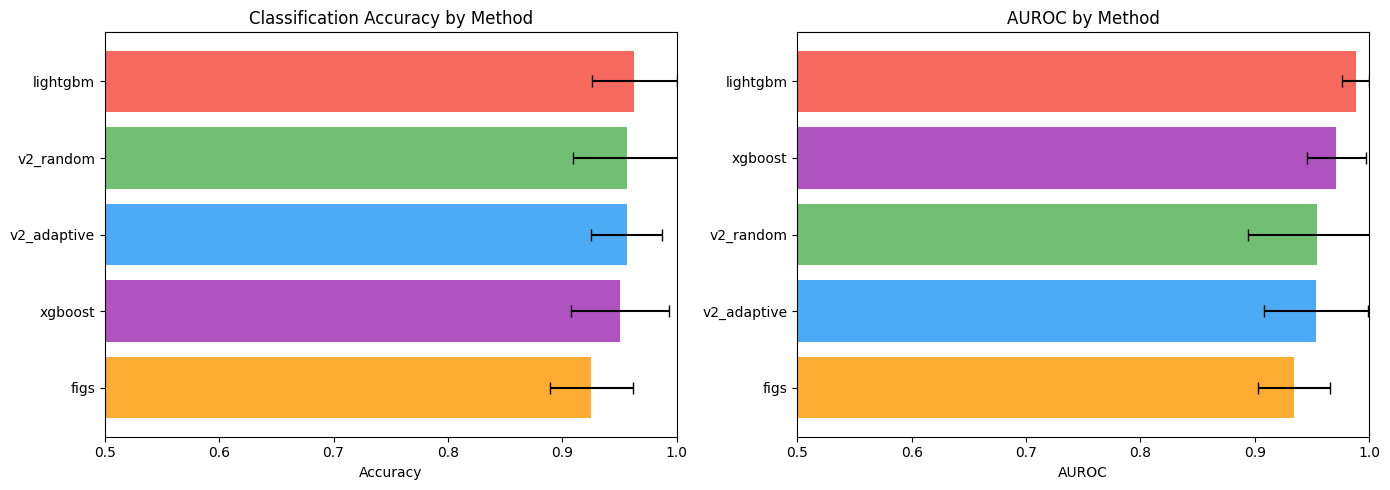

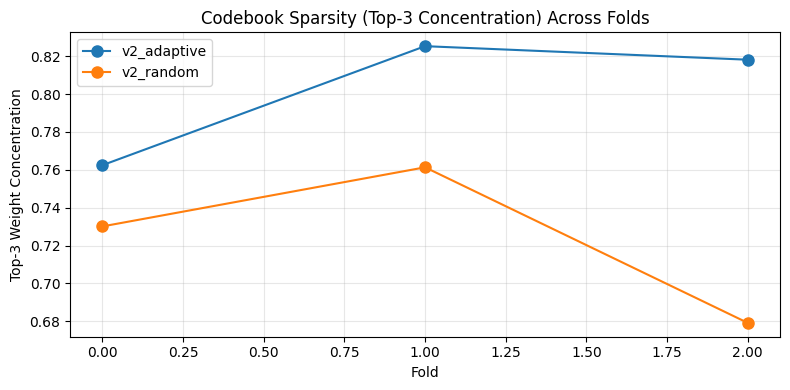


Experiment completed in 37.4s


In [13]:
import pandas as pd

# ── Summary Table ────────────────────────────────────────────────────
df = pd.DataFrame(all_results)
print("=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)

# Build summary: mean accuracy/auroc per (config, K)
summary_rows = []
for (config, K), grp in df.groupby(["config", "K"], dropna=False):
    row = {"Method": config, "K": K if pd.notna(K) else "-"}
    if grp["accuracy"].notna().any():
        row["Acc (mean)"] = f"{grp['accuracy'].mean():.3f}"
        row["Acc (std)"] = f"{grp['accuracy'].std():.3f}"
    if grp["auroc"].notna().any():
        row["AUROC (mean)"] = f"{grp['auroc'].mean():.3f}"
    if grp["erank"].notna().any():
        row["eRank"] = f"{grp['erank'].mean():.2f}"
    if grp["top3_concentration"].notna().any():
        row["Top3 Conc"] = f"{grp['top3_concentration'].mean():.3f}"
    if grp["train_time_sec"].notna().any():
        row["Time (s)"] = f"{grp['train_time_sec'].mean():.2f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# ── Bar Chart: Accuracy Comparison ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy by method
acc_data = df[df["accuracy"].notna()].groupby("config")["accuracy"].agg(["mean", "std"]).reset_index()
acc_data = acc_data.sort_values("mean", ascending=True)

colors = []
for c in acc_data["config"]:
    if "adaptive" in str(c):
        colors.append("#2196F3")
    elif "random" in str(c):
        colors.append("#4CAF50")
    elif c == "figs":
        colors.append("#FF9800")
    elif c == "xgboost":
        colors.append("#9C27B0")
    elif c == "lightgbm":
        colors.append("#F44336")
    else:
        colors.append("#607D8B")

axes[0].barh(acc_data["config"], acc_data["mean"], xerr=acc_data["std"],
             color=colors, alpha=0.8, capsize=4)
axes[0].set_xlabel("Accuracy")
axes[0].set_title("Classification Accuracy by Method")
axes[0].set_xlim(0.5, 1.0)

# Plot 2: AUROC by method
auroc_data = df[df["auroc"].notna()].groupby("config")["auroc"].agg(["mean", "std"]).reset_index()
auroc_data = auroc_data.sort_values("mean", ascending=True)

colors2 = []
for c in auroc_data["config"]:
    if "adaptive" in str(c):
        colors2.append("#2196F3")
    elif "random" in str(c):
        colors2.append("#4CAF50")
    elif c == "figs":
        colors2.append("#FF9800")
    elif c == "xgboost":
        colors2.append("#9C27B0")
    elif c == "lightgbm":
        colors2.append("#F44336")
    else:
        colors2.append("#607D8B")

axes[1].barh(auroc_data["config"], auroc_data["mean"], xerr=auroc_data["std"],
             color=colors2, alpha=0.8, capsize=4)
axes[1].set_xlabel("AUROC")
axes[1].set_title("AUROC by Method")
axes[1].set_xlim(0.5, 1.0)

plt.tight_layout()
plt.savefig("results_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

# ── Sparsity Analysis ────────────────────────────────────────────────
v2_results = df[df["method"] == "codebook_figs_v2"]
if not v2_results.empty and v2_results["top3_concentration"].notna().any():
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    for config_name, grp in v2_results.groupby("config"):
        fold_data = grp.groupby("fold")["top3_concentration"].mean()
        ax2.plot(fold_data.index, fold_data.values, 'o-', label=config_name, markersize=8)
    ax2.set_xlabel("Fold")
    ax2.set_ylabel("Top-3 Weight Concentration")
    ax2.set_title("Codebook Sparsity (Top-3 Concentration) Across Folds")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("sparsity_analysis.png", dpi=100, bbox_inches="tight")
    plt.show()

print(f"\nExperiment completed in {total_time:.1f}s")